In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Confirm the MAR pattern first
print(df[df['TotalCharges'].isnull()]['tenure'].unique())  # should show [0]

[0]


In [5]:
df_orders = pd.read_csv('../data/raw/ecommerce/olist_orders_dataset.csv')
date_cols = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
             'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# For delivery-time analysis, filter to only delivered orders
delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()
print(f"Filtered from {len(df_orders)} to {len(delivered)} delivered orders")

Filtered from 99441 to 96478 delivered orders


In [6]:
# Demonstration: if a categorical column had nulls, mode = most frequent value
print(df['Contract'].mode()[0])  # shows the most common contract type
# df['SomeColumn'].fillna(df['SomeColumn'].mode()[0], inplace=True)

Month-to-month


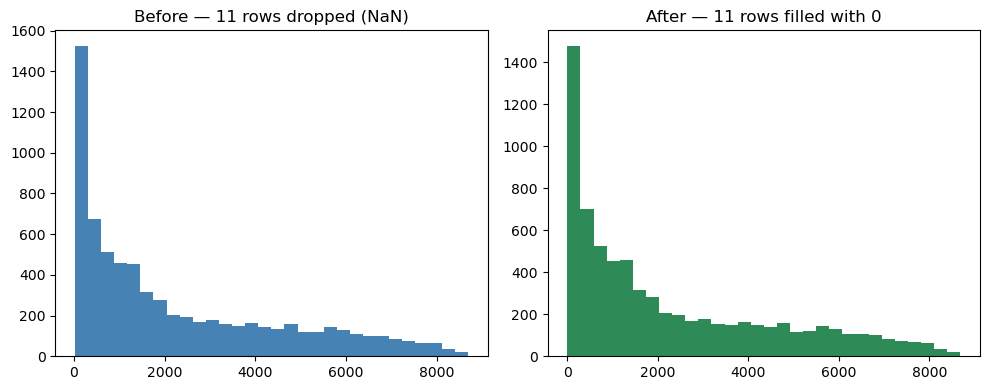

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_before = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_before['TotalCharges'] = pd.to_numeric(df_before['TotalCharges'], errors='coerce')

axes[0].hist(df_before['TotalCharges'].dropna(), bins=30, color='steelblue')
axes[0].set_title('Before — 11 rows dropped (NaN)')

axes[1].hist(df['TotalCharges'], bins=30, color='seagreen')
axes[1].set_title('After — 11 rows filled with 0')

plt.tight_layout()
plt.show()

## Missing Value Strategy — Day 3

### Dataset 1: Telco Customer Churn — TotalCharges (11 missing)

**Category:** MAR (Missing At Random)
**Evidence:** All 11 rows with missing TotalCharges have tenure = 0.
Confirmed by checking df[df['TotalCharges'].isnull()]['tenure'].unique() → [0]

**Why MAR:** The missingness is fully explained by another visible column
(tenure). These are brand-new customers who haven't received a bill yet —
there is no "total charged" value because no billing cycle has occurred.

**Strategy applied:** Filled with 0 (domain logic), NOT median.

**Why not median:** Using the median (~$1,397) would invent a billing
history that never existed for these customers. Since we know exactly
WHY the value is missing (tenure=0 → no bills sent), 0 is the only
logically correct value — not a statistical guess.

**Before/after check:** Compared histograms of TotalCharges before and
after the fix. The distribution shape is nearly identical — a single
small new bar appears at 0 (11 rows out of 7,043 = 0.16%). Negligible
impact on the overall distribution, as expected for a tiny, well
understood fix.

---

### Dataset 2: Brazilian E-Commerce — order_delivered_customer_date (2,965 missing)

Investigated by splitting the missing values into two groups based on
order_status.

**Group A — 2,957 rows (99.7% of missing values)**
**Category:** MAR
**Evidence:** order_status breakdown for missing rows:
  shipped=1107, canceled=619, unavailable=609, invoiced=314, processing=301
**Why MAR:** Explained entirely by order_status. An order that is
cancelled, still in transit, or still processing cannot have a delivery
date yet — the blank reflects a real, ongoing order lifecycle, not an error.
**Strategy applied:** Left as NaT. No imputation. These rows are
excluded from delivery-time calculations by filtering on
order_status == 'delivered' before any date-difference analysis.
**Why not impute:** There is no valid date to invent for an order that
was never delivered. Filling it in would corrupt any delivery-time
or on-time-rate analysis.

**Group B — 8 rows (0.3% of missing values)**
**Category:** MCAR (best available evidence — not provable with
certainty, but no contradicting pattern was found)
**Evidence:** All 8 rows have order_status = 'delivered' (meaning they
were actually delivered) yet the delivery date is blank — a direct
contradiction. Investigated for a common cause:
  - Checked order_purchase_timestamp for clustering → spread across
    13 months (2017-05-25 to 2018-07-01), only 3 of 8 share one day
  - One row (index 92643) is missing BOTH carrier date and delivery
    date, suggesting a logging failure rather than a delivery failure
**Why MCAR:** No column in the dataset explains why these 8 specific
rows (out of 96,478 delivered orders) are missing their date. The order
itself was completed successfully — only the data entry for that one
field failed. This points to a random recording accident, unrelated to
anything else we can observe.
**Strategy applied:** Left as-is, flagged as a known data quality issue
in the report. Not imputed.
**Why not impute:** With only 8 affected rows out of 99,441 (0.008%),
any imputation strategy (mean, mode, nearest-neighbour estimate) would
add more noise than it removes. The honest choice is to document the
issue rather than mask it with an invented value.

---

### Categorical missing values — mode strategy (reference)

Neither dataset has missing categorical columns, so mode imputation
was not needed in practice. For future reference: mode (most frequent
category) is only appropriate when missingness is confirmed MCAR.
For MAR/MNAR categorical columns, domain logic should always be
checked first — exactly the same principle applied to TotalCharges
above.

### Summary

| Column | Missing | Category | Strategy |
|---|---|---|---|
| Telco: TotalCharges | 11 | MAR | Filled with 0 (domain logic) |
| Orders: delivery date (Group A) | 2,957 | MAR | Left as NaT, filtered by status |
| Orders: delivery date (Group B) | 8 | MCAR | Left as-is, flagged as data issue |